In [1]:
# ============================================================
# 🔥 ONE-TIME EMBEDDING CREATION
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
import os

# -------------------------
# CONFIG
# -------------------------
EMB_DIM_IN = 768
EMB_DIM_OUT = 128

DRG_PATH  = r"C:\Arun_MIX\Model\20260325_DRG_Emb_Clinical_bert.xlsx"
ICD_PATH  = r"C:\Arun_MIX\Model\20260325_ICD_Emb_Clinical_bert.xlsx"
PROC_PATH = r"C:\Arun_MIX\Model\20260325_PROC_Emb_Clinical_bert.xlsx"

SAVE_PATH = r"C:\Arun_MIX\Model\API\embeddings.pkl"
PROJECTION_PATH = r"C:\Arun_MIX\Model\API\projection_768_to_128.pth"

torch.manual_seed(42)

# -------------------------
# LOAD / CREATE PROJECTION
# -------------------------
def get_projection():
    projection = nn.Linear(EMB_DIM_IN, EMB_DIM_OUT)

    if os.path.exists(PROJECTION_PATH):
        projection.load_state_dict(torch.load(PROJECTION_PATH))
        print("✅ Loaded projection")
    else:
        torch.save(projection.state_dict(), PROJECTION_PATH)
        print("✅ Saved new projection")

    projection.eval()
    return projection


# -------------------------
# PROCESS FUNCTION
# -------------------------
def process(df, col, projection):
    df[col] = df[col].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=' ')
        if isinstance(x, str) else x
    )

    emb = torch.tensor(np.vstack(df[col].values), dtype=torch.float32)
    return projection(emb).detach().numpy()


# -------------------------
# BUILD DICTS
# -------------------------
def build_dicts():
    projection = get_projection()

    # DRG
    drg = pd.read_excel(DRG_PATH)
    drg["DRG_EMB_128"] = list(process(drg, "DRG_EMBEDDING", projection))
    drg["DRG_Code"] = drg["DRG_TEXT"].str.extract(r"DRG Code:\s*(\d+)")[0]
    drg_dict = dict(zip(drg["DRG_Code"], drg["DRG_EMB_128"]))

    # ICD
    icd = pd.read_excel(ICD_PATH)
    icd["ICD_EMB_128"] = list(process(icd, "ICD_EMBEDDING", projection))
    icd_dict = dict(zip(icd["SDX_CODE"], icd["ICD_EMB_128"]))

    # PROC
    proc = pd.read_excel(PROC_PATH)
    proc["PROC_EMB_128"] = list(process(proc, "PROC_EMBEDDING", projection))
    proc_dict = dict(zip(proc["PX_CODE"], proc["PROC_EMB_128"]))

    return drg_dict, icd_dict, proc_dict


# -------------------------
# SAVE PKL
# -------------------------
def save_pkl():
    drg_dict, icd_dict, proc_dict = build_dicts()

    with open(SAVE_PATH, "wb") as f:
        pickle.dump({
            "drg_dict": drg_dict,
            "icd_dict": icd_dict,
            "proc_dict": proc_dict
        }, f)

    print(f"\n✅ embeddings.pkl saved at: {SAVE_PATH}")


# -------------------------
# RUN
# -------------------------
if __name__ == "__main__":
    save_pkl()

✅ Saved new projection

✅ embeddings.pkl saved at: C:\Arun_MIX\Model\API\embeddings.pkl


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [ ]:
df_hum_hist.tail()

,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID
76354,Strat,1214224,Hum,HUPTMR-63729,820251960252063,PostPay,10,4634.96,570331865,000067133E,SELF REGIONAL HEALTH CARE,2,01-ROUTINE/HOME,5602,2025,7,18,1,0,0,0,MCD93,2025-09-19,2025-10-07,O6981X0,O721 - CC,Z370,Z91048,Z7982,Z3A39,O7182,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Y,N,<NA>,<NA>,<NA>,<NA>,N,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,10E0XZZ,10907ZC,3E0P7VZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,"805D,803D",5601,O6981X0,Z3A39,Z91048,Z7982,Z3A39,O7182,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Y,1,1,1,1,N,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,10E0XZZ,10907ZC,3E0P7VZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"Labor and delivery complicated by cord around neck, without compression, not applicable or unspecified",Other immediate postpartum hemorrhage,Single live birth,Other nonmedicinal substance allergy status,Long term (current) use of aspirin,39 weeks gestation of pregnancy,Other specified trauma to perin

In [6]:
drg_desc = pd.read_excel(r"C:\Users\arunkumara\Downloads\20260323_DRG_Desp.xls",dtype='str')
drg_desc.shape

df_hist = df_hum_hist.merge(drg_desc,left_on='ADRG',right_on='DRGCode',how='left')

#df_drg = df_drg[~(df_drg['DRGCode'].isnull())]
df_hist.shape

(76355, 294)

In [7]:
df_drg = df_hist[~(df_hist['DRGCode'].isnull())]
df_drg.shape

(74326, 294)

In [8]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_drg.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(74326, 294)
(74326, 294)
<StringArray>
['01', '10']
Length: 2, dtype: string
(74322, 294)
len_adrg
3    74322
Name: count, dtype: int64
Group_Type
01    74319
10        3
Name: count, dtype: Int64
(74319, 295)
Control_ID
HUPTMR-50715    1
HUPTMR-71432    1
HUPRMR-1533     1
HUPRMR-9433     1
HUPRMR-9418     1
Name: count, dtype: Int64
(74319, 296)
(74318, 296)
(74316, 296)
(74316, 296)


(74316, 299)

In [9]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(74316, 299)


len_adrg
3    74316
Name: count, dtype: int64

In [10]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]


df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()


# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))



def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)


mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))



def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,DRGCode,DRGDesc,Type,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,A_DX_List_Clean,A_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [9]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(72556, 309)


In [10]:
df_post = df_with_sdx[df_with_sdx['PaymentType']=='PostPay']
print(df_post.shape)

(63625, 309)


In [11]:
# ✅ Define columns to keep
cols_to_keep = [
    "Control_ID", "Claim_Number", "PaymentType", "Group_Type", "Payments",
    "Tax_ID", "Provider_ID", "HospitalName", "LOS", "AGE", "ADRG","PRIM_DX",
     "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_DX_MCC_Count","A_DX_CC_Count",
    "A_PX_List",

    # Target / Outcome
    "InitialDeterminationStatus", "IDSavings"
]

# ✅ Keep only available columns (avoids errors if some missing)
cols_existing = [col for col in cols_to_keep if col in df.columns]

# ✅ Filter dataframe
df_final = df[cols_existing]

# ✅ Optional: check result
print("Final shape:", df_final.shape)
print("Columns kept:", len(cols_existing))

Final shape: (74316, 20)
Columns kept: 20


In [16]:
df_final[df_final['InitialDeterminationStatus']=='DENIED'].head(10)

,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,AGE,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_PX_List,InitialDeterminationStatus,IDSavings
39,HUPTMR-71794,820253350390879,PostPay,01,35041.06,621596506,000047750D,EAST JEFFERSON GENERAL HOSPITA,19,70,853,A4101,"E43,J155,J690,R6521","D62,E870,E871,I5032,K9422,K9423,L03311,T8131XA,Z1612,Z681","C320,D638,E785,E8339,E8342,E876,F17210,G8929,I110,J392",4,10,"0CBM0ZX,0KXJ0ZZ,0WQ60ZZ,30233N1,5A1955Z",DENIED,8246.29
40,HUPTMR-71637,820252600611877,PostPay,01,23385.71,591713947,000198266,JACKSON MEMORIAL HOSPITAL,19,67,871,A419,"J189,R6520","I421,J9811,R64,Z681,Z940","D329,D638,D75839,E213,E559,E875,G588,G8929,I10,I361,I4710,M810,M8588,Z1152,Z79621,Z7982,Z79899",2,5,"02HV33Z,0B9G8ZX,B030YZZ,B236YZZ,B24BYZZ,B548ZZA",DENIED,8972.91
41,HUPTMR-71380,820253490447224,PostPay,01,9157.70,710240352,000066011C,MERCY HOSPITAL FORT SMITH,6,78,189,J9621,"I5033,J189","C3412,J440,J441,J9819,K5190,L03116","D6481,E1140,E1151,E782,F32A,I110,I2510,I480,K5641,Q2381,T451X5A,Z7901,Z7902,Z86718,Z89511,Z9981",2,6,,DENIED,867.62
42,HUPTMR-70832,820253100802581,PostPay,01,11563.54,560789196,560789196,"HOSPITAL, CATAWBA MEMORIAL",4,70,640,E871,N186,"I120,N179","D631,E039,E1122,E1151,E785,E860,G20A1,G894,I2510,I4891,J449,M810,R531,R5381,R5383,T501X5A,Z8673,Z89611,Z90710,Z992",1,2,,DENIED,3169.44
43,HUPTMR-71545,820253320322953,PostPay,01,10914.74,621596506,000047750D,EAST JEFFERSON GENERAL HOSPITA,11,64,698,T8619,E43,"A0472,E871,I130,I428,N12,N179,T8613,Z1629","B961,D702,D84821,E1122,E11319,E1151,E8339,E860,E876,I2510,I509,K2100,N189,T375X5A,Z794",1,8,"05HA33Z,0TB03ZX",DENIED,2937.52
44,HUPTMR-71648,820253260267499,PostPay,01,6891.02,202848116,202848116,TX HEALTH ROCKWALL,6,76,190,J441,"J189,J9601","D62,E871,J440,J45901,K922","E785,F329,G43909,I10,K2100,K2270,M4312,M47812,M4802,M542,R109,Z7951,Z7982,Z79899,Z885,Z90710",2,5,,DENIED,1951.15
130,HUPTMR-52573,820250740250094,PostPay,01,8315.33,571098556,000285184X,MUSC HEALTH COLUMBIA MEDICAL C,6,78,637,E1165,"G9341,I21A1",S42202A,"D72829,E1122,E869,E8720,F01B0,I129,I480,N1831,Z794,Z8673",2,1,,DENIED,3570.23
159,HUPTMR-68759,820250971085024,PostPay,01,6736.63,363386394,363386394A,BANNER BAYWOOD MEDICAL,5,82,190,J441,"J189,J9601",J440,"E83119,E876,F0390,F17210,I2489,K589",2,1,,DENIED,2036.8
160,HUPTMR-69082,820250620511226,PostPay,01,7585.26,853777599,853777599B,NOVANT NEW HANOVER REGIONAL ME,15,75,190,J441,J9621,"E440,I5032,N179,R7881,Z681","B957,D649,E1122,E860,F17210,I252,I480,N1831,N401,R338,Z1152,Z66,Z7901,Z800,Z8249,Z825,Z8673",1,5,,DENIED,2312.18
161,HUPTMR-69218,820250550474116,PostPay,01,41326.81,853777599,853777599B,NOVANT NEW HANOVER REGIONAL ME,8,66,853,A411,"A401,A4181,E43,J189,J869,J9601,R6520","E871,J440,J90,R64,Z681","D509,E785,E860,F17210,F909,I10,I2510,J4530,J8283,M1990,M5030",7,5,"02HV33Z,0BNL4ZZ,0W9B3ZZ,0W9B40Z",DENIED,3289.03


In [12]:
df_final.head(10)

,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,AGE,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_PX_List,InitialDeterminationStatus,IDSavings
0,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,52,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,0.0
1,HUPTMR-72007,820253180530927,PostPay,01,11699.99,566017737,566017737F,WAKEMED RALEIGH CAMPUS,7,85,193,J189,"I5033,J9601",E873,"E039,E1165,E785,F0394,F419,I110,K219,K5900,K7469,Z1152,Z66,Z794,Z79890,Z79899,Z87440",2,1,"5A0945A,B32T1ZZ",APPROVED,0.0
2,HUPTMR-68811,820251200832345,PostPay,01,15543.60,900054201,900054201,BANNER DESERT MEDICAL,6,71,377,K921,"J9601,N186","D62,I132,I5032,Z6841","D631,E1122,E6601,E66813,E785,E8351,G4733,I2510,I2720,I4891,J449,Z8673,Z955,Z992",2,4,"5A09357,5A1D70Z",APPROVED,0.0
3,HUPTMR-71494,820253280447437,PostPay,01,15628.23,160743102,160743102A,OLEAN GENERAL HOSPITAL,10,67,871,A419,"G9341,J189,J690,J9601,R532,R6521","E870,R64","D696,D72819,E119,E7800,E8339,E860,E861,E876,F0280,F79,G20A1,G40909,I959,J9809,N3281,R4182",6,2,"0BH17EZ,5A09357,5A1945Z",APPROVED,0.0
4,HUPTMR-64090,820251920785407,PostPay,01,11594.74,592142859,000198453,SHANDS JACKSONVILLE MEDICAL CE,4,90,200,J95811,,"C3412,E440,E871","E1140,E1165,E7800,F17210,J449,N3020,N401,R338,R54,Z6821,Z7984,Z79899,Z8546,Z85828,Z86718,Z87442",0,3,"0BBG3ZX,0W9B30Z",APPROVED,0.0
5,HUPTMR-63832,820251960391857,PostPay,01,12471.44,221494440,221494440A,COOPERMAN BARNABAS MEDICAL CEN,7,45,811,D5700,"G9341,N186","E441,E871,L97918,L97928,N2581,R188,R6510,Z681","D631,D696,E8339,E8352,G8929,I739,I959,R7401,Z1152,Z7409,Z79899,Z881,Z91048,Z992",2,8,"30233N1,5A1D70Z",APPROVED,0.0
6,HUPRMR-10618,820260560737025,Prepay,01,4912.17,830343789,830343789,WILKES REGIONAL MEDICAL CENTER,4,72,683,N179,,,"E8720,F03911,F1010,F17210,F419,G43909,J449,K219,M79605,M797,R197,R531,Z7409,Z9181",0,0,,APPROVED,0.0
7,HUPTMR-57538,820251390637571,PostPay,01,5567.63,610482973,610482973,JENNIE STUART MEDICAL CENTER,1,38,948,G893,,C569,"D630,F17210,F32A,F419,J45909,K7460,Z79899",0,1,,APPROVED,0.0
8,HUPRMR-10635,820260560732252,Prepay,01,6303.08,621636465,000060303P,HOLSTON VALLEY MED CTR,3,69,683,N179,,"E871,I120,N10,N185","D509,E1122,E1165,E669,E785,E8720,E875,F32A,F419,G4730,G8929,K219,K760,T368X5A,Z6838,Z794,Z8616,Z881,Z882,Z9089",0,4,,APPROVED,0.0
9,HUPTMR-59237,820250150704769,PostPay,01,12927.15,610654587,610654587,BAPTIST HEALTH DEACONESS MADIS,8,69,465,T8453XA,,T8484XA,"E782,I10,K219,M1990,M810,Z888,Z90710,Z96651",0,1,"05HB33Z,0SHC08Z,0SPC0JZ,3E0U029,B54MZZA",APPROVED,0.0


# Emd

## DRG

In [13]:
drg_emb = pd.read_excel(r"C:\Arun_MIX\Model\20260325_DRG_Emb_Clinical_bert.xlsx")
drg_emb.head(1)

DRG_TEXT  \
0  DRG Code: 616. Description: Amputation of Lower Limb for Endocrine, Nutritional and Metabolic Disorders with MCC   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [14]:
drg_emb["DRG_EMBEDDING"] = drg_emb["DRG_EMBEDDING"].apply(
    lambda x: np.round(np.fromstring(x.strip("[]"), sep=' '), 5) if isinstance(x, str) else np.round(x, 5)
)

import torch
import torch.nn as nn

# Convert to tensor
emb_tensor = torch.tensor(np.vstack(drg_emb["DRG_EMBEDDING"].values), dtype=torch.float32)

# Linear projection 768 -> 128
projection = nn.Linear(768, 128)

# Forward pass
reduced_emb = projection(emb_tensor).detach().numpy()

# Store
drg_emb["DRG_EMB_128"] = list(reduced_emb)

drg_emb["DRG_Code"] = (
    drg_emb["DRG_TEXT"]
    .str.extract(r"DRG Code:\s*(\d+)")[0]   # 👈 select column
    .str.strip()
)

In [15]:
drg_dict = dict(zip(drg_emb["DRG_Code"], drg_emb["DRG_EMB_128"]))

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\2127211349.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["DRG_EMB_128"] = df_final["ADRG"].map(drg_dict)


## ICD

In [17]:
icd_emb = pd.read_excel(r"C:\Arun_MIX\Model\20260325_ICD_Emb_Clinical_bert.xlsx")
#icd_emb.head(1)

In [18]:
icd_emb["ICD_EMBEDDING"] = icd_emb["ICD_EMBEDDING"].apply(
    lambda x: np.round(np.fromstring(x.strip("[]"), sep=' '), 5) if isinstance(x, str) else np.round(x, 5)
)

import torch
import torch.nn as nn

# Convert to tensor
emb_tensor = torch.tensor(np.vstack(icd_emb["ICD_EMBEDDING"].values), dtype=torch.float32)

# Linear projection 768 -> 128
projection = nn.Linear(768, 128)

# Forward pass
reduced_emb = projection(emb_tensor).detach().numpy()

# Store
icd_emb["ICD_EMB_128"] = list(reduced_emb)
icd_dict = dict(zip(icd_emb["SDX_CODE"], icd_emb["ICD_EMB_128"]))

In [19]:
df_final["PDX_EMB_128"] = df_final["PRIM_DX"].map(drg_dict)

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\382740420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["PDX_EMB_128"] = df_final["PRIM_DX"].map(drg_dict)


In [20]:
def map_icd_embeddings(code_str, icd_dict):
    if pd.isna(code_str):
        return None
    
    codes = code_str.split(",")   # split multiple codes
    
    # get embeddings (ignore missing codes)
    emb_list = [icd_dict.get(code.strip()) for code in codes if code.strip() in icd_dict]
    
    return emb_list if emb_list else None


df_final["MCC_EMB_LIST"] = df_final["A_DX_MCC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

df_final["CC_EMB_LIST"] = df_final["A_DX_CC_Set"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\4245568503.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["MCC_EMB_LIST"] = df_final["A_DX_MCC_Set"].apply(
C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\4245568503.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["CC_EMB_LIST"] = df_final["A_DX_CC_Set"].apply(


## Proce

In [21]:
proc_emb = pd.read_excel(r"C:\Arun_MIX\Model\20260325_PROC_Emb_Clinical_bert.xlsx")
#proc_emb.head(1)

In [22]:
proc_emb["PROC_EMBEDDING"] = proc_emb["PROC_EMBEDDING"].apply(
    lambda x: np.round(np.fromstring(x.strip("[]"), sep=' '), 5) if isinstance(x, str) else np.round(x, 5)
)

import torch
import torch.nn as nn

# Convert to tensor
emb_tensor = torch.tensor(np.vstack(proc_emb["PROC_EMBEDDING"].values), dtype=torch.float32)

# Linear projection 768 -> 128
projection = nn.Linear(768, 128)

# Forward pass
reduced_emb = projection(emb_tensor).detach().numpy()

# Store
proc_emb["PROC_EMB_128"] = list(reduced_emb)
proc_dict = dict(zip(proc_emb["PX_CODE"], proc_emb["PROC_EMB_128"]))

In [23]:
df_final["PROC_EMB_LIST"] = df_final["A_PX_List"].apply(
    lambda x: map_icd_embeddings(x, icd_dict)
)

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\3653265434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["PROC_EMB_LIST"] = df_final["A_PX_List"].apply(


# Model

In [ ]:
df_final.head(1)

In [24]:

df_ml_new = df_final.copy()
# ============================================================
# Encode Target
# ============================================================
df_ml_new["Status_binary"] = df_ml_new["InitialDeterminationStatus"].map({
    "APPROVED": 0,
    "DENIED": 1
})

In [25]:
# ============================================================
# 🔥 FULL HEALTHCARE CLAIMS PIPELINE – DIMENSION-SAFE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
emb_dim = 128  # fixed embedding dimension



# ============================================================
# Helper functions for embedding padding

import math

def fix_single(x, emb_dim=128):
    # Handle None, NaN, empty list → zeros
    if x is None or (isinstance(x, float) and math.isnan(x)) or (hasattr(x, "__len__") and len(x) == 0):
        return torch.zeros(emb_dim)
    
    # Convert to tensor
    x = torch.tensor(x, dtype=torch.float32)
    
    # Pad or trim to emb_dim
    if x.numel() < emb_dim:
        x = F.pad(x, (0, emb_dim - x.numel()))
    elif x.numel() > emb_dim:
        x = x[:emb_dim]
    return x

def fix_multi(x, emb_dim=128):
    if x is None or (isinstance(x, float) and math.isnan(x)) or (hasattr(x, "__len__") and len(x) == 0):
        return torch.zeros(1, emb_dim)
    
    x = torch.tensor(x, dtype=torch.float32)
    
    # Single row → reshape
    if x.ndim == 1:
        if x.numel() < emb_dim:
            x = F.pad(x, (0, emb_dim - x.numel()))
        elif x.numel() > emb_dim:
            x = x[:emb_dim]
        return x.view(1, emb_dim)
    
    # Multi-row → pad each row
    if x.shape[1] != emb_dim:
        diff = emb_dim - x.shape[1]
        if diff > 0:
            x = F.pad(x, (0, diff))
        else:
            x = x[:, :emb_dim]
    return x.view(-1, emb_dim)

# ============================================================
# Dataset
# ============================================================
class HealthDataset(Dataset):
    def __init__(self, df, emb_dim=emb_dim):
        self.DRG = [fix_single(x, emb_dim) for x in df["DRG_EMB_128"]]
        self.PRIM = [fix_single(x, emb_dim) for x in df["PDX_EMB_128"]]
        self.MCC = [fix_multi(x, emb_dim) for x in df["MCC_EMB_LIST"]]
        self.CC = [fix_multi(x, emb_dim) for x in df["CC_EMB_LIST"]]
        self.PROC = [fix_multi(x, emb_dim) for x in df["PROC_EMB_LIST"]]
        self.LOS = torch.tensor(df["LOS"].values, dtype=torch.float32)
        self.Payments = torch.tensor(df["Payments"].values, dtype=torch.float32)
        self.y = torch.tensor(df["Status_binary"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "DRG": self.DRG[idx],
            "PRIM": self.PRIM[idx],
            "MCC": self.MCC[idx],
            "CC": self.CC[idx],
            "PROC": self.PROC[idx],
            "LOS": self.LOS[idx].unsqueeze(0),
            "Payments": self.Payments[idx].unsqueeze(0),
            "y": self.y[idx]
        }

# Collate function
def health_collate_fn(batch):
    return {
        "DRG": [b["DRG"] for b in batch],
        "PRIM": [b["PRIM"] for b in batch],
        "MCC": [b["MCC"] for b in batch],
        "CC": [b["CC"] for b in batch],
        "PROC": [b["PROC"] for b in batch],
        "LOS": torch.stack([b["LOS"] for b in batch]),
        "Payments": torch.stack([b["Payments"] for b in batch]),
        "y": torch.stack([b["y"] for b in batch]),
    }

# ============================================================
# Attention Pooling
# ============================================================
class AttentionPooling(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(emb_dim))
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.register_buffer("zero_vec", torch.zeros(emb_dim))

    def forward(self, X):
        # X shape: (n_tokens, emb_dim)
        if X.shape[0] == 0:
            return self.zero_vec
        elif X.shape[0] == 1:
            return X.squeeze(0)
        Q = self.query.unsqueeze(0)
        K = self.key(X)
        V = self.value(X)
        attn = torch.softmax(Q @ K.T / np.sqrt(K.shape[1]), dim=-1)
        return (attn @ V).squeeze(0)

# ============================================================
# Neural Network
# ============================================================
class HealthNN(nn.Module):
    def __init__(self, emb_dim=emb_dim):
        super().__init__()
        self.mcc_attn = AttentionPooling(emb_dim)
        self.cc_attn = AttentionPooling(emb_dim)
        self.proc_attn = AttentionPooling(emb_dim)
        self.fc1 = nn.Linear(emb_dim*5 + 2, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, batch):
        drg = torch.stack(batch["DRG"])
        prim = torch.stack(batch["PRIM"])
        mcc = torch.stack([self.mcc_attn(x) for x in batch["MCC"]])
        cc = torch.stack([self.cc_attn(x) for x in batch["CC"]])
        proc = torch.stack([self.proc_attn(x) for x in batch["PROC"]])
        los = torch.stack([x for x in batch["LOS"]])
        payments = torch.stack([x for x in batch["Payments"]])
        X = torch.cat([drg, prim, mcc, cc, proc, los, payments], dim=1)
        x = F.relu(self.bn1(self.fc1(X)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        return self.out(x).squeeze(1)

# ============================================================
# Train / Validation / Test Split
# ============================================================
df_train, df_temp = train_test_split(df_ml_new, test_size=0.1,
                                     stratify=df_ml_new["Status_binary"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.2,
                                   stratify=df_temp["Status_binary"], random_state=42)

train_ds = HealthDataset(df_train)
val_ds = HealthDataset(df_val)
test_ds = HealthDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=health_collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=health_collate_fn)

# ============================================================
# Model + Loss (imbalance aware)
# ============================================================
model = HealthNN(emb_dim=emb_dim).to(device)
pos = df_train["Status_binary"].sum()
neg = len(df_train) - pos
pos_weight = torch.tensor([neg / pos], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# ============================================================
# Training Loop
# ============================================================
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["y"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    y_val, y_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
            logits = model(batch)
            y_val.append(batch["y"].cpu())
            y_prob.append(torch.sigmoid(logits).cpu())
    y_val = torch.cat(y_val)
    y_prob = torch.cat(y_prob)
    y_pred = (y_prob >= 0.5).int()
    print(f"Epoch {epoch+1} | Loss {total_loss:.4f} | Recall {recall_score(y_val, y_pred):.4f} | F1 {f1_score(y_val, y_pred):.4f}")



C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_2044\1704298368.py:42: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x = torch.tensor(x, dtype=torch.float32)


Epoch 1 | Loss 2541.2040 | Recall 0.7270 | F1 0.2453
Epoch 2 | Loss 2494.3257 | Recall 0.6699 | F1 0.2561
Epoch 3 | Loss 2442.6227 | Recall 0.7145 | F1 0.2750
Epoch 4 | Loss 2386.7153 | Recall 0.6574 | F1 0.2918
Epoch 5 | Loss 2386.1795 | Recall 0.7409 | F1 0.2794
Epoch 6 | Loss 2348.7582 | Recall 0.6184 | F1 0.3141
Epoch 7 | Loss 2314.4027 | Recall 0.7646 | F1 0.3044
Epoch 8 | Loss 2264.7302 | Recall 0.6448 | F1 0.3401
Epoch 9 | Loss 2234.4659 | Recall 0.8384 | F1 0.3098
Epoch 10 | Loss 2213.3862 | Recall 0.6950 | F1 0.3491
Epoch 11 | Loss 2228.6496 | Recall 0.9429 | F1 0.2620
Epoch 12 | Loss 2210.5321 | Recall 0.6504 | F1 0.3502
Epoch 13 | Loss 2198.0911 | Recall 0.4304 | F1 0.3936
Epoch 14 | Loss 2185.9858 | Recall 0.6699 | F1 0.3663
Epoch 15 | Loss 2183.3397 | Recall 0.7897 | F1 0.3264
Epoch 16 | Loss 2187.9291 | Recall 0.6950 | F1 0.3662
Epoch 17 | Loss 2184.2383 | Recall 0.8231 | F1 0.3309
Epoch 18 | Loss 2173.7708 | Recall 0.8273 | F1 0.3008
Epoch 19 | Loss 2157.4279 | Recall 0.

In [40]:
model.eval()
y_true, y_prob = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()

# ✅ Use fixed threshold
best_thr = 0.55

print("\n✅ Best Threshold:", best_thr)

# Apply threshold
y_pred = (y_prob >= best_thr).astype(int)

# Final report
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.55

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9484    0.6881    0.7975      1308
         1.0     0.2416    0.7263    0.3626       179

    accuracy                         0.6927      1487
   macro avg     0.5950    0.7072    0.5801      1487
weighted avg     0.8633    0.6927    0.7452      1487



In [41]:
# ============================================================
# 💾 SAVE MODEL
# ============================================================

save_path = "20260326_health_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "emb_dim": emb_dim,
    "threshold": best_thr
}, save_path)

print(f"✅ Model saved to {save_path}")

✅ Model saved to 20260326_health_model.pth


In [42]:
# ============================================================
# 📦 LOAD MODEL
# ============================================================

def load_model(model_path, device="cpu"):
    checkpoint = torch.load(model_path, map_location=device)

    model = HealthNN(emb_dim=checkpoint["emb_dim"])
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    threshold = checkpoint.get("threshold", 0.55)

    return model, threshold

In [44]:
model, threshold = load_model("20260326_health_model.pth")

In [46]:
threshold

0.55

In [45]:
model

HealthNN(
  (mcc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (cc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (proc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=642, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)

In [43]:
print(model)

HealthNN(
  (mcc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (cc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (proc_attn): AttentionPooling(
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc1): Linear(in_features=642, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)



✅ Test Accuracy: 0.6927

Confusion Matrix:
 [[900 408]
 [ 49 130]]


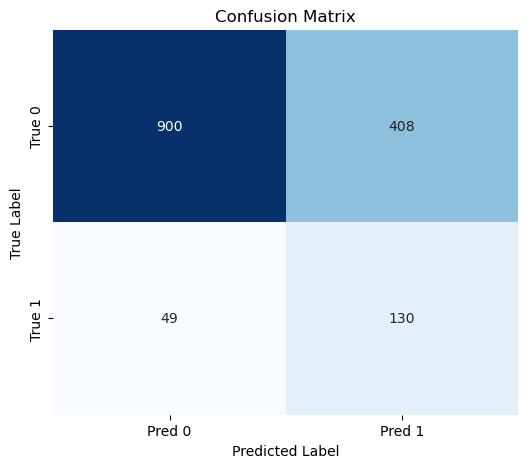

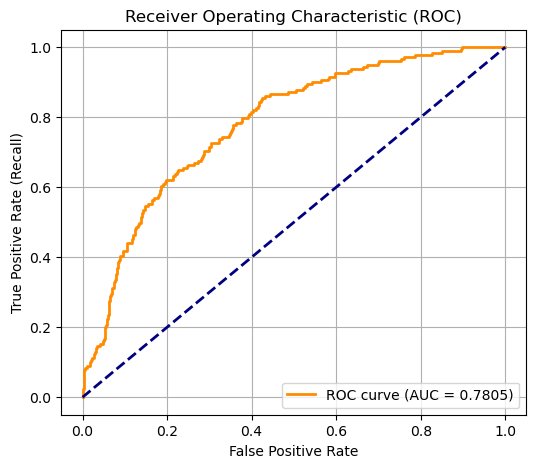

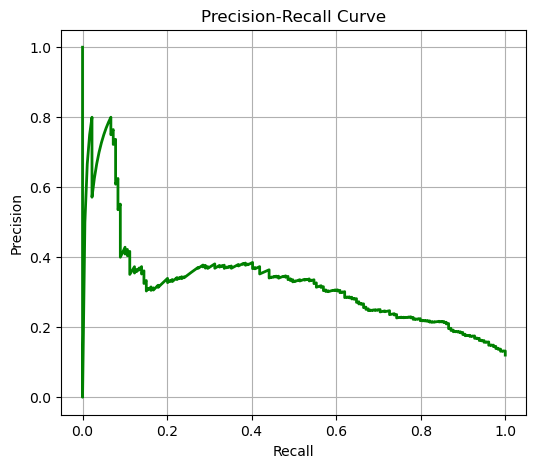

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Accuracy & Confusion Matrix
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle

torch.manual_seed(42)

projection = nn.Linear(768, 128)
torch.save(projection.state_dict(), "projection_768_to_128.pth")


def process(df, col):
    df[col] = df[col].apply(
        lambda x: np.fromstring(x.strip("[]"), sep=' ') if isinstance(x, str) else x
    )
    emb = torch.tensor(np.vstack(df[col].values), dtype=torch.float32)
    return projection(emb).detach().numpy()


# DRG
drg = pd.read_excel(r"C:\Arun_MIX\Model\20260325_DRG_Emb_Clinical_bert.xlsx")
drg["DRG_EMB_128"] = list(process(drg, "DRG_EMBEDDING"))
drg["DRG_Code"] = drg["DRG_TEXT"].str.extract(r"DRG Code:\s*(\d+)")[0]
drg_dict = dict(zip(drg["DRG_Code"], drg["DRG_EMB_128"]))

# ICD
icd = pd.read_excel(r"C:\Arun_MIX\Model\20260325_ICD_Emb_Clinical_bert.xlsx")
icd["ICD_EMB_128"] = list(process(icd, "ICD_EMBEDDING"))
icd_dict = dict(zip(icd["SDX_CODE"], icd["ICD_EMB_128"]))

# PROC
proc = pd.read_excel(r"C:\Arun_MIX\Model\20260325_PROC_Emb_Clinical_bert.xlsx")
proc["PROC_EMB_128"] = list(process(proc, "PROC_EMBEDDING"))
proc_dict = dict(zip(proc["PX_CODE"], proc["PROC_EMB_128"]))

with open("embeddings.pkl", "wb") as f:
    pickle.dump({
        "drg_dict": drg_dict,
        "icd_dict": icd_dict,
        "proc_dict": proc_dict
    }, f)

print("✅ embeddings.pkl created")

✅ embeddings.pkl created


# prev

In [39]:
# ============================================================
# Test Evaluation + Balanced Threshold
# ============================================================
model.eval()
y_true, y_prob = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) if torch.is_tensor(v) else v for k,v in batch.items()}
        logits = model(batch)
        y_true.append(batch["y"].cpu())
        y_prob.append(torch.sigmoid(logits).cpu())

y_true = torch.cat(y_true).numpy()
y_prob = torch.cat(y_prob).numpy()
best_thr, best_bal = 0.5, 0
for t in np.linspace(0.05, 0.95, 200):
    y_pred = (y_prob >= t).astype(int)
    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)
    bal = (r0 + r1)/2
    if bal > best_bal:
        best_bal, best_thr = bal, t

print("\n✅ Best Threshold:", round(best_thr,4))
print("✅ Balanced Recall:", round(best_bal,4))
y_pred = (y_prob >= best_thr).astype(int)
print("\n📊 Final Test Report\n")
print(classification_report(y_true, y_pred, digits=4))


✅ Best Threshold: 0.4344
✅ Balanced Recall: 0.7142

📊 Final Test Report

              precision    recall  f1-score   support

         0.0     0.9674    0.5680    0.7158      1308
         1.0     0.2142    0.8603    0.3430       179

    accuracy                         0.6032      1487
   macro avg     0.5908    0.7142    0.5294      1487
weighted avg     0.8768    0.6032    0.6709      1487



# both pre and post


✅ Test Accuracy: 0.7054

Confusion Matrix:
 [[924 384]
 [ 54 125]]


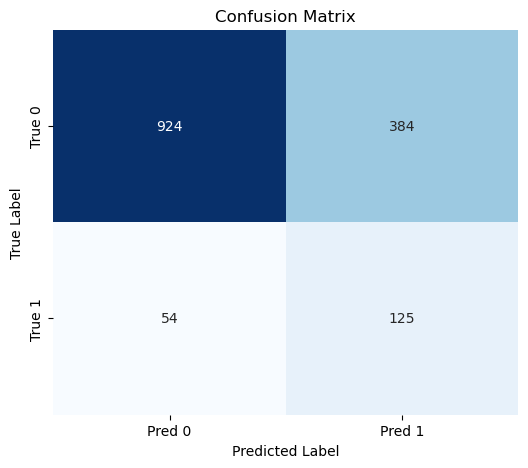

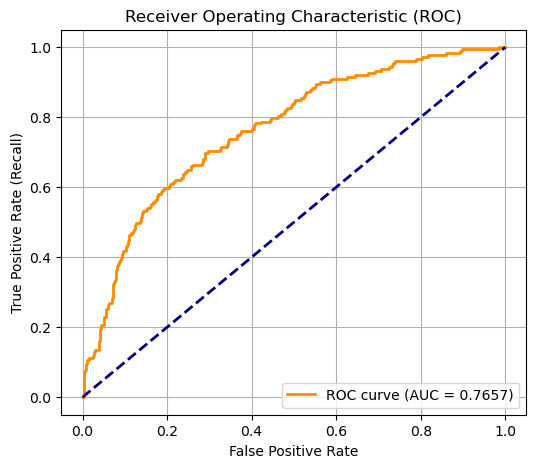

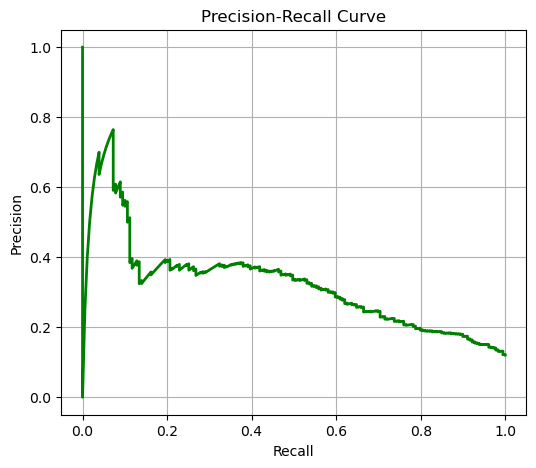

In [90]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Accuracy & Confusion Matrix
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\n✅ Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# -----------------------------
# Precision-Recall Curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# prediction

In [91]:
import torch
import torch.nn.functional as F

def predict_claim_from_codes(
    model,
    drg_code, prim_dx, mcc_list=None, cc_list=None, proc_list=None,
    LOS=0.0, Payments=0.0,
    drg_dict=None, icd_dict=None, proc_dict=None,
    emb_dim=128,
    threshold=0.4796
):
    model.eval()
    
    # -------------------------
    # Helper functions
    # -------------------------
    def fix_single(x):
        if x is None:
            return torch.zeros(emb_dim)
        x = torch.tensor(x, dtype=torch.float32)
        if x.numel() < emb_dim:
            x = F.pad(x, (0, emb_dim - x.numel()))
        elif x.numel() > emb_dim:
            x = x[:emb_dim]
        return x

    def fix_multi(code_list, dict_map):
        if code_list is None or len(code_list) == 0:
            return torch.zeros(1, emb_dim)
        embs = []
        for code in code_list:
            emb = dict_map.get(code, [0.0]*emb_dim)
            embs.append(emb)
        embs = torch.tensor(embs, dtype=torch.float32)
        return embs.view(-1, emb_dim)
    
    # -------------------------
    # Map codes → embeddings
    # -------------------------
    drg = fix_single(drg_dict.get(drg_code, [0.0]*emb_dim)).unsqueeze(0).to(device)
    prim = fix_single(icd_dict.get(prim_dx, [0.0]*emb_dim)).unsqueeze(0).to(device)
    mcc = fix_multi(mcc_list, icd_dict).to(device)
    cc = fix_multi(cc_list, icd_dict).to(device)
    proc = fix_multi(proc_list, proc_dict).to(device)
    
    los = torch.tensor([[LOS]], dtype=torch.float32, device=device)
    payments = torch.tensor([[Payments]], dtype=torch.float32, device=device)
    
    # -------------------------
    # Attention pooling + forward
    # -------------------------
    with torch.no_grad():
        mcc_attn = torch.stack([model.mcc_attn(mcc)])
        cc_attn = torch.stack([model.cc_attn(cc)])
        proc_attn = torch.stack([model.proc_attn(proc)])

        X = torch.cat([drg, prim, mcc_attn, cc_attn, proc_attn, los, payments], dim=1)
        logits = model.out(F.relu(model.fc3(F.relu(model.bn2(model.fc2(F.relu(model.bn1(model.fc1(X)))))))))
        prob_denied = torch.sigmoid(logits).item()
        pred_class = "Denied" if prob_denied >= threshold else "Approved"
    
    return pred_class, prob_denied

In [92]:
# Example codes
drg_code = "175"
prim_dx = "I2699"
mcc_list = ["N186"]
cc_list = ["I132,I483,I5032,N2581"]
proc_list = ["5A1D70Z"]

LOS_example = 3
Payments_example = 9198.88

pred_class, denied_prob = predict_claim_from_codes(
    model,
    drg_code, prim_dx, mcc_list, cc_list, proc_list,
    LOS_example, Payments_example,
    drg_dict=drg_dict, icd_dict=icd_dict, proc_dict=proc_dict,
    threshold=0.4796
)

print(f"Prediction: {pred_class}")
print(f"Confidence score for Denied: {denied_prob:.4f}")

Prediction: Denied
Confidence score for Denied: 0.5963
